# DES Y6 covariance forecast

A **covariance matrix** C gives the expected scatter of every data-vector entry and the correlation between any two entries: $C_{ij}=\langle(d_i-\bar d_i)(d_j-\bar d_j)\rangle$, where d is a measured data vector and $\bar d$ its mean. A likelihood uses its inverse in $\chi^2=(d-m)^{\mathsf T}C^{-1}(d-m)$, with m the model prediction.

This notebook forecasts C for the DES Y6 3×2pt real-space data vector: **six lens bins, four source bins and 26 angular bins**, ordered as ξ+, ξ−, γt and w. That is 1,300 entries, so C is a **1,300 × 1,300** matrix. It is computed in three parts, and the total is their sum:

| Component | Physical origin |
|---|---|
| Gaussian (G) | The scatter a Gaussian random field would give: products of signal-plus-noise power spectra, including galaxy shape noise and shot noise |
| Super-sample (SSC) | Matter fluctuations larger than the survey footprint raise or lower the mean density of the whole survey, which changes the small-scale power everywhere in the same direction |
| Connected non-Gaussian (cNG) | The connected four-point function (trispectrum) of the nonlinear matter field, from the halo model |

Use this notebook to inspect intermediate quantities. For production or HPC work, run `covariance/compute_covariance.py` with `EXAMPLE_EVALUATE_COVARIANCE.yaml`; its direct bindings avoid the notebook wrappers' array conversions. Both routes call the same C kernels.

This is an **analogous forecast**, not a released DES Y6 likelihood. The active dataset uses dummy data and a unit covariance. The separate `DESY6.cov` has 1,690 entries and no verified mapping to this layout, so it is not compared here. See [survey inputs and model limits](covariance/README.md).

The default build omits covariance generation. Unset `IGNORE_COSMOLIKE_DES_Y6_COVARIANCE` and recompile, as `covariance/README.md` describes, then activate Cocoa and export `OMP_NUM_THREADS` before opening Jupyter. Restart the kernel after recompiling the interface.


## Set up the kernel

The next cell prepares paths, threads and figure style:

- `ROOTDIR`, exported by `start_cocoa.sh`, is the `cocoa/Cocoa` folder. The cell puts four folders first on Python's import path: `cosmolike_core` for the shared package `cosmolike_notebook_utils`, Cocoa's CAMB, the project's `interface/` for the compiled module `cosmolike_des_y6_interface` (imported as `ci`) and `covariance/` for the DES Y6 adapter `des_y6_covariance.py` (imported as `survey`).
- The compiled loops run on `OMP_NUM_THREADS` OpenMP threads, applied by `ci.set_omp_threads`. The linear-algebra library (BLAS) stays at one thread so it does not compete with those loops.
- `cov` holds the shared covariance calculations and diagnostics, `pcov` the covariance figures and `save_forecast` the archive writer.


In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
# The variables reach only BLAS libraries loaded after this point;
# threadpool_limits below also caps one that is already loaded.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
# Position 0 puts these folders ahead of installed packages with the same
# module names, so CAMB is Cocoa's build.
root = Path(os.environ["ROOTDIR"])
project = root/"projects/des_y6"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

# Draw figures inside the notebook, at twice the pixel density (retina).
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
# ci.has_covariance is False when the build omits covariance generation.
import cosmolike_des_y6_interface as ci
import des_y6_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.forecast import save_forecast

# Caps BLAS at one thread for the rest of the session;
# blas_limit.restore_original_limits() undoes it.
blas_limit = threadpool_limits(limits=1, user_api="blas")
# A KeyError here means OMP_NUM_THREADS was not exported before Jupyter started.
threads = int(os.environ["OMP_NUM_THREADS"])
ci.set_omp_threads(n=threads)
# Fonts and styles belong to the notebook; the shared plotters never set them.
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams.update({
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.right": False,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.labelsize": "medium",
    "axes.grid": True,
    "grid.linewidth": 0.0,
    "grid.alpha": 0.18,
    "grid.color": "lightgray",
    "legend.labelspacing": 0.77,
    "savefig.bbox": "tight",
    "savefig.format": "pdf",
})


## Choose the forecast

`survey.configuration` returns every survey and numerical choice in one dictionary, `settings`. The next cell prints these entries:

| Key | Meaning | Units |
|---|---|---|
| `area_deg2` | Survey area | deg² |
| `lens_density_arcmin2` | Number density n of each lens bin | galaxies per arcmin² |
| `source_density_arcmin2` | Effective number density n of each source bin | galaxies per arcmin² |
| `sigma_e_component` | Shape dispersion $\sigma_e$: scatter of one ellipticity component of a single source galaxy | dimensionless |
| `bias` | Linear galaxy bias $b_1$ of each lens bin | dimensionless |
| `cosmology` | CAMB inputs of the forecast | as in the evaluate YAMLs |
| `accuracy_parameters` | Base numerical controls read from `covariance/default.yaml` | mixed |

Published catalogue values set the densities, dispersions and area; the normalized n(z) files set only the radial shape of each bin. The densities fix the noise: **shape noise** $\sigma_e^2/n$ for a source bin and **shot noise** $1/n$ for a lens bin, with n per steradian.

The forecast uses **massless neutrinos**, because its halo-model terms require them. It also uses Takahashi Halofit nonlinear power, linear galaxy bias, a **spherical-cap footprint** (a circular patch of sky with the survey's area) and no magnification or redshift-space distortions (RSD). The data-vector notebooks use 0.06 eV of neutrino mass and HMcode 2020 instead, so their mean signals differ slightly from this forecast's.

Gaussian galaxy–galaxy (gg) and galaxy–shear (gs) spectra include the **non-Limber** correction, which keeps the radial mode coupling that the Limber approximation drops; shear–shear remains Limber. Set `ia` to `NLA` or `TATT`, with amplitudes, to add Gaussian intrinsic alignments. SSC and cNG always keep the zero-IA Limber matter model.

`accuracy_boost` refines interpolation tables and multipole cutoffs: 1 is the `default.yaml` baseline, and 2, 4 and 8 refine it. `integration_accuracy` independently selects the quadrature rule, from 96 nodes at level 0 to 1,024 at level 4. The covariance power preparation has 11,993 wavenumbers and does not change ordinary likelihood power tables.

`survey.initialize` runs CAMB once and installs the cosmology, n(z), biases and zero nuisance shifts in the compiled module. It returns the CAMB tables, which the last cell saves.


In [2]:
# accuracy_boost=1 is the default.yaml baseline (2, 4 and 8 refine tables and
# cutoffs); integration_accuracy=0 selects the 96-node quadrature rule.
settings = survey.configuration(
    accuracy_boost=1,
    integration_accuracy=0,
    # Non-Limber gg/gs Gaussian spectra without IA; SSC and cNG ignore this.
    gaussian={"nonlimber": True, "ia": "none"},
)
# Units: deg^2, galaxies per arcmin^2, dispersion of one shear component.
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
):
    print(key, settings[key])
# Runs CAMB and installs cosmology, n(z), biases and zero nuisance shifts in ci.
camb_tables = survey.initialize(interface=ci, settings=settings)
# The OpenMP team size is process-wide and code run during initialization
# may change it; set it again before the covariance kernels.
ci.set_omp_threads(n=threads)


def progress(stage, elapsed):
    """Print elapsed seconds at each completed covariance construction stage."""
    # {elapsed:8.2f} prints the seconds with 2 decimals in an 8-character field.
    print(f"{elapsed:8.2f} s  {stage}")


area_deg2 4031.04
lens_density_arcmin2 [0.128, 0.092, 0.097, 0.123, 0.096, 0.097]
source_density_arcmin2 [2.05, 2.1, 2.14, 2.32]
sigma_e_component [0.265, 0.287, 0.282, 0.347]
bias [1.54, 1.81, 1.85, 1.76, 1.93, 1.9]
cosmology {'omegam': 0.319, 'omegab': 0.049, 'H0': 67.0, 'ns': 0.96, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 1, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}


## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space: the part of the four-point function that
products of two-point functions do not capture. The **halo model** places all
matter in halos, bound clumps of dark matter, so the four density factors can
live in one, two, three or four halos. It separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
The cell below chooses one redshift, z = 0.5, and plots the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the project's covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$, so the
cell multiplies k in $h/\mathrm{Mpc}$ by $c/H_0=2997.92458\,\mathrm{Mpc}/h$
and converts the output trispectrum back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.


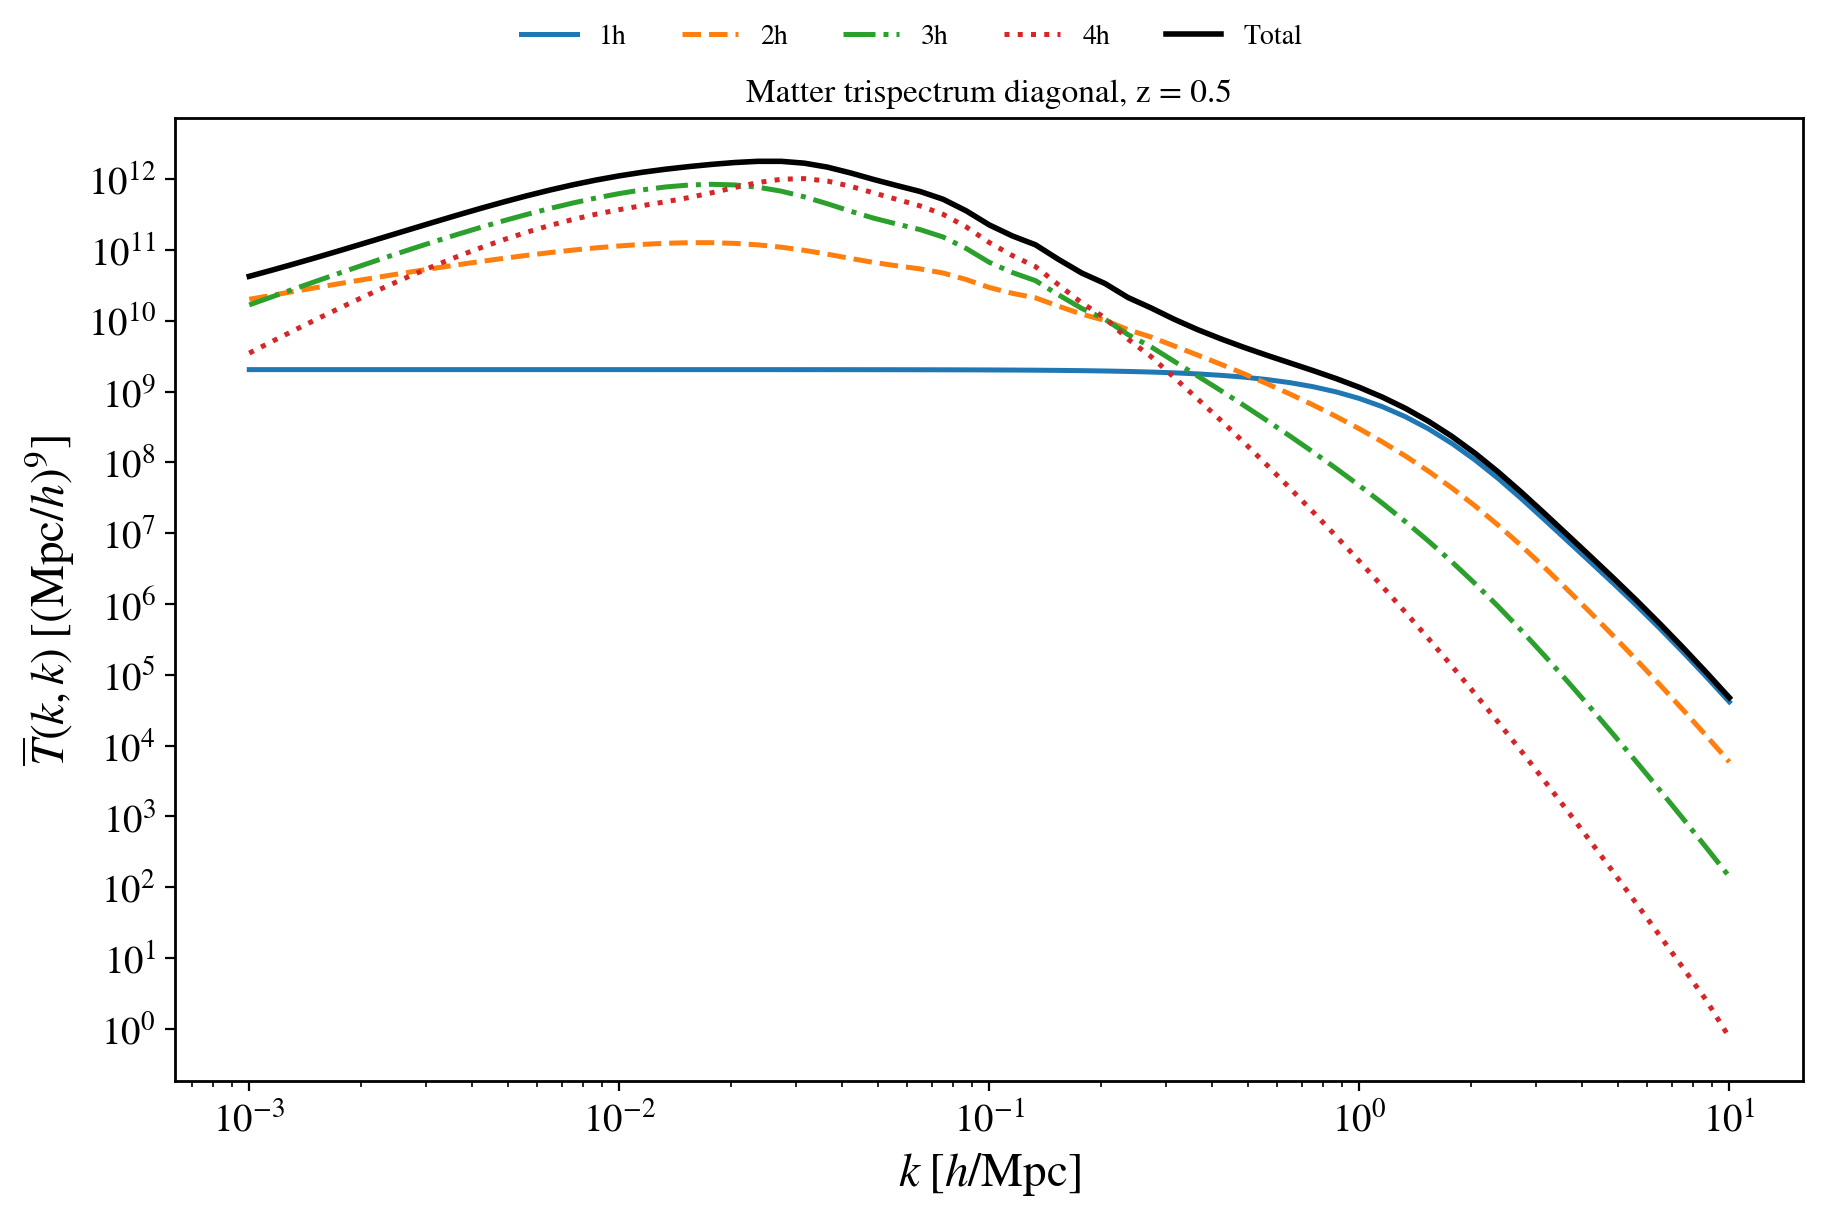

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute the complete matrix

`survey.compute` assembles G, SSC and cNG for every pair of the 1,300 entries. Entries are ordered by probe, then by tomographic pair, with the 26 angular bins of each pair consecutive:

| Block | Tomographic pairs | Entries | Matrix indices |
|---|---|---|---|
| ξ+ | 10 source pairs (1,1), (1,2), …, (4,4) | 260 | 0–259 |
| ξ− | the same 10 source pairs | 260 | 260–519 |
| γt | 24 (lens, source) pairs, lens-major: (1,1), (1,2), …, (6,4) | 624 | 520–1143 |
| w | 6 lens auto-correlations | 156 | 1144–1299 |

`forecast["rows"]` lists the 50 tomographic pairs as (probe, field A, field B). Probes 0, 1, 2 and 3 are ξ+, ξ−, γt and w; fields 0–5 are lens bins 1–6 and fields 6–9 are source bins 1–4. A covariance block also needs spectra absent from the data vector: the Gaussian covariance of w in lens bins 1 and 2 contains the cross-spectrum of those two bins. The calculation includes all of them.

The progress lines print elapsed seconds after each stage. The `Matter shell` lines count the radial integration nodes, thin shells at fixed distance, at which the shared halo response and trispectrum tables are built; that stage takes most of the time.

`space="fourier"` produces an illustrative 600-entry matrix in 15 multipole bands. Its ordering differs from the real-space likelihood, so the real-space mask must not be applied to it.


In [4]:
forecast = survey.compute(
    interface=ci,
    settings=settings,
    space="real",
    progress=progress,
)
# forecast holds gaussian, ssc, cng and total [1300, 1300] (dimensionless),
# plus signal, rows, coordinate (bin centers in arcmin) and the settings.
print("Full covariance shape:", forecast["total"].shape)
# 26 angular bins times 10 source pairs (xi+ and xi-), 24 lens-source pairs
# (gamma_t) and 6 lens bins (w).
block_sizes = [260, 260, 624, 156]
block_labels = [r"$\xi_+$", r"$\xi_-$", r"$\gamma_t$", r"$w$"]


    1.50 s  all_pairs_gaussian_spectra


    3.04 s  angular_and_mask_geometry


    5.68 s  gaussian_blocks
    5.88 s  observable_signal


    6.49 s  Matter shell 1/672


   14.45 s  Matter shell 33/672


...

  147.28 s  Matter shell 577/672


  155.12 s  Matter shell 609/672


  162.92 s  Matter shell 641/672


  170.42 s  shared_halo_response_and_trispectrum


  170.67 s  ssc_and_connected_projection
  170.67 s  total
Full covariance shape: (1300, 1300)


## Inspect every component

The first figure is the **correlation matrix** of the total covariance, $r_{ij}=C_{ij}/\sqrt{C_{ii}C_{jj}}$. Dividing by the standard deviations removes the very different variances of shear and clustering entries, so $r_{ij}$, between −1 and 1, compares how strongly any two entries vary together. Index 0 is at the bottom left; the lines separate ξ+, ξ−, γt and w.

The second figure shows the **component maps**: G, SSC and cNG, each divided by the same total-diagonal factor $\sqrt{C^{\rm total}_{ii}C^{\rm total}_{jj}}$. Each map keeps its signs, so a negative cross term stays visible; the histogram collects the same values.

The cell then checks that each component is finite and exactly symmetric, and tests whether the total is **positive definite**: every linear combination of entries must have a positive variance, which is also the condition for $C^{-1}$ in $\chi^2$ to exist. `cov.covariance_modes` tests this on the correlation matrix. That matrix has the same numbers of positive and negative eigenvalues as C, but its eigenvalues are not swamped by round-off from the large spread of raw variances. No eigenvalue is clipped or repaired.


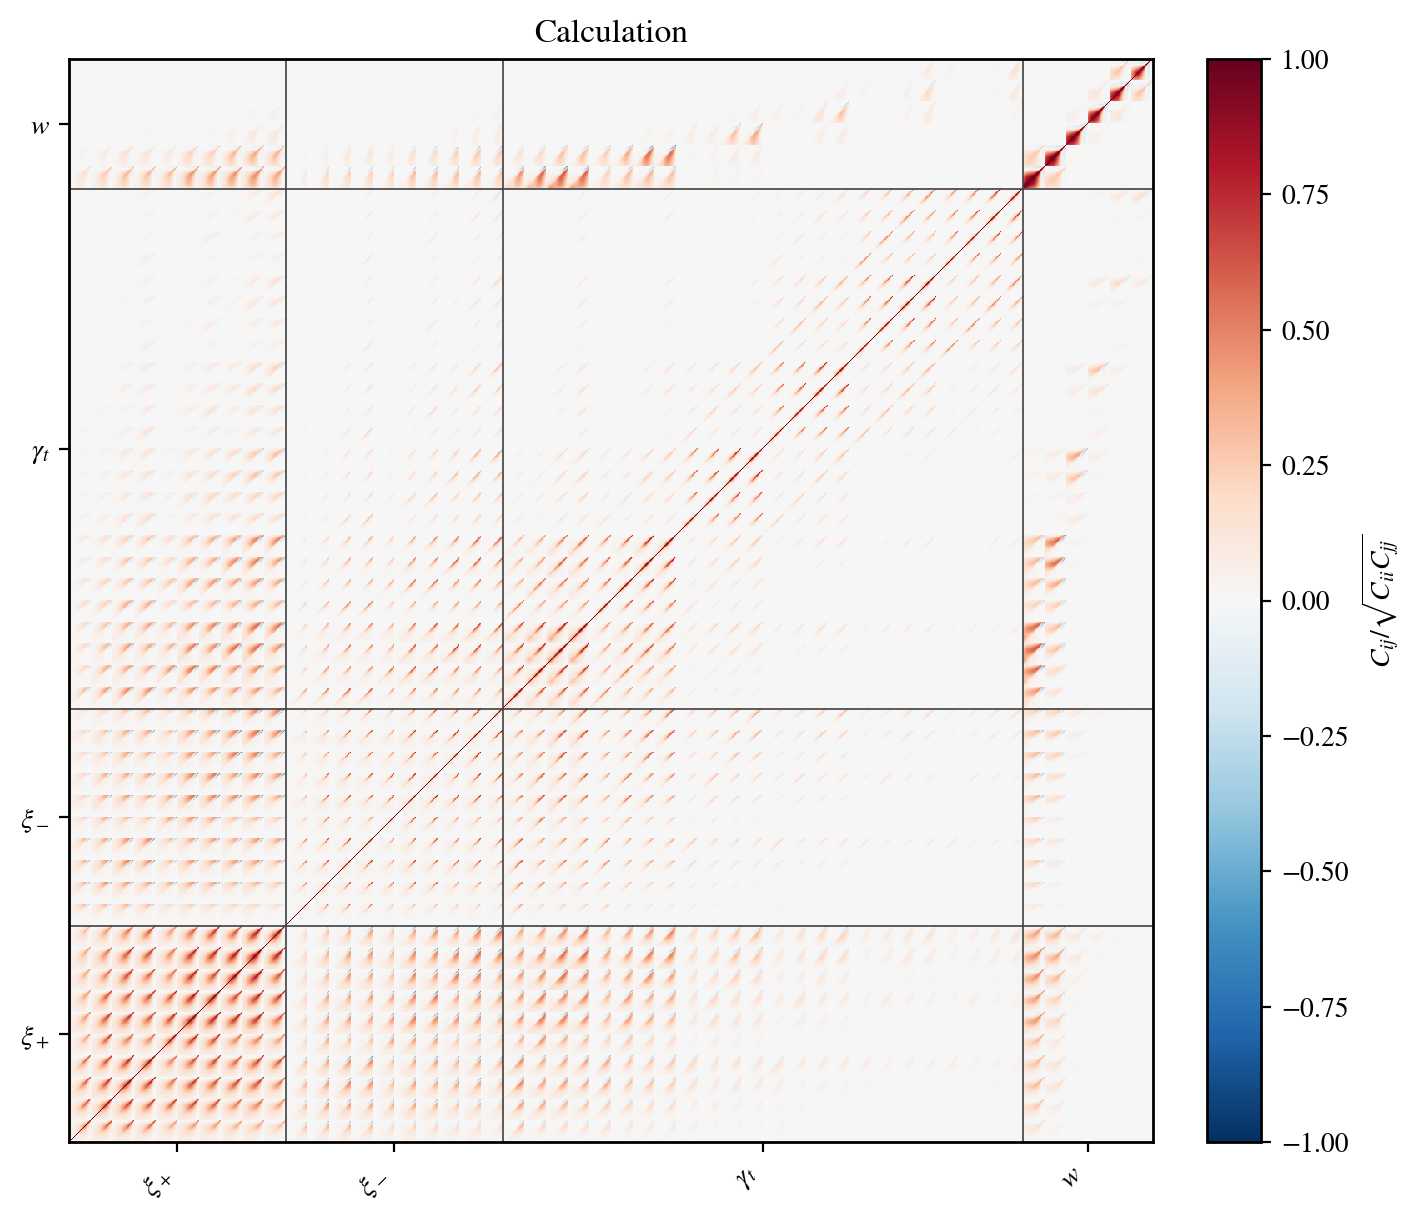

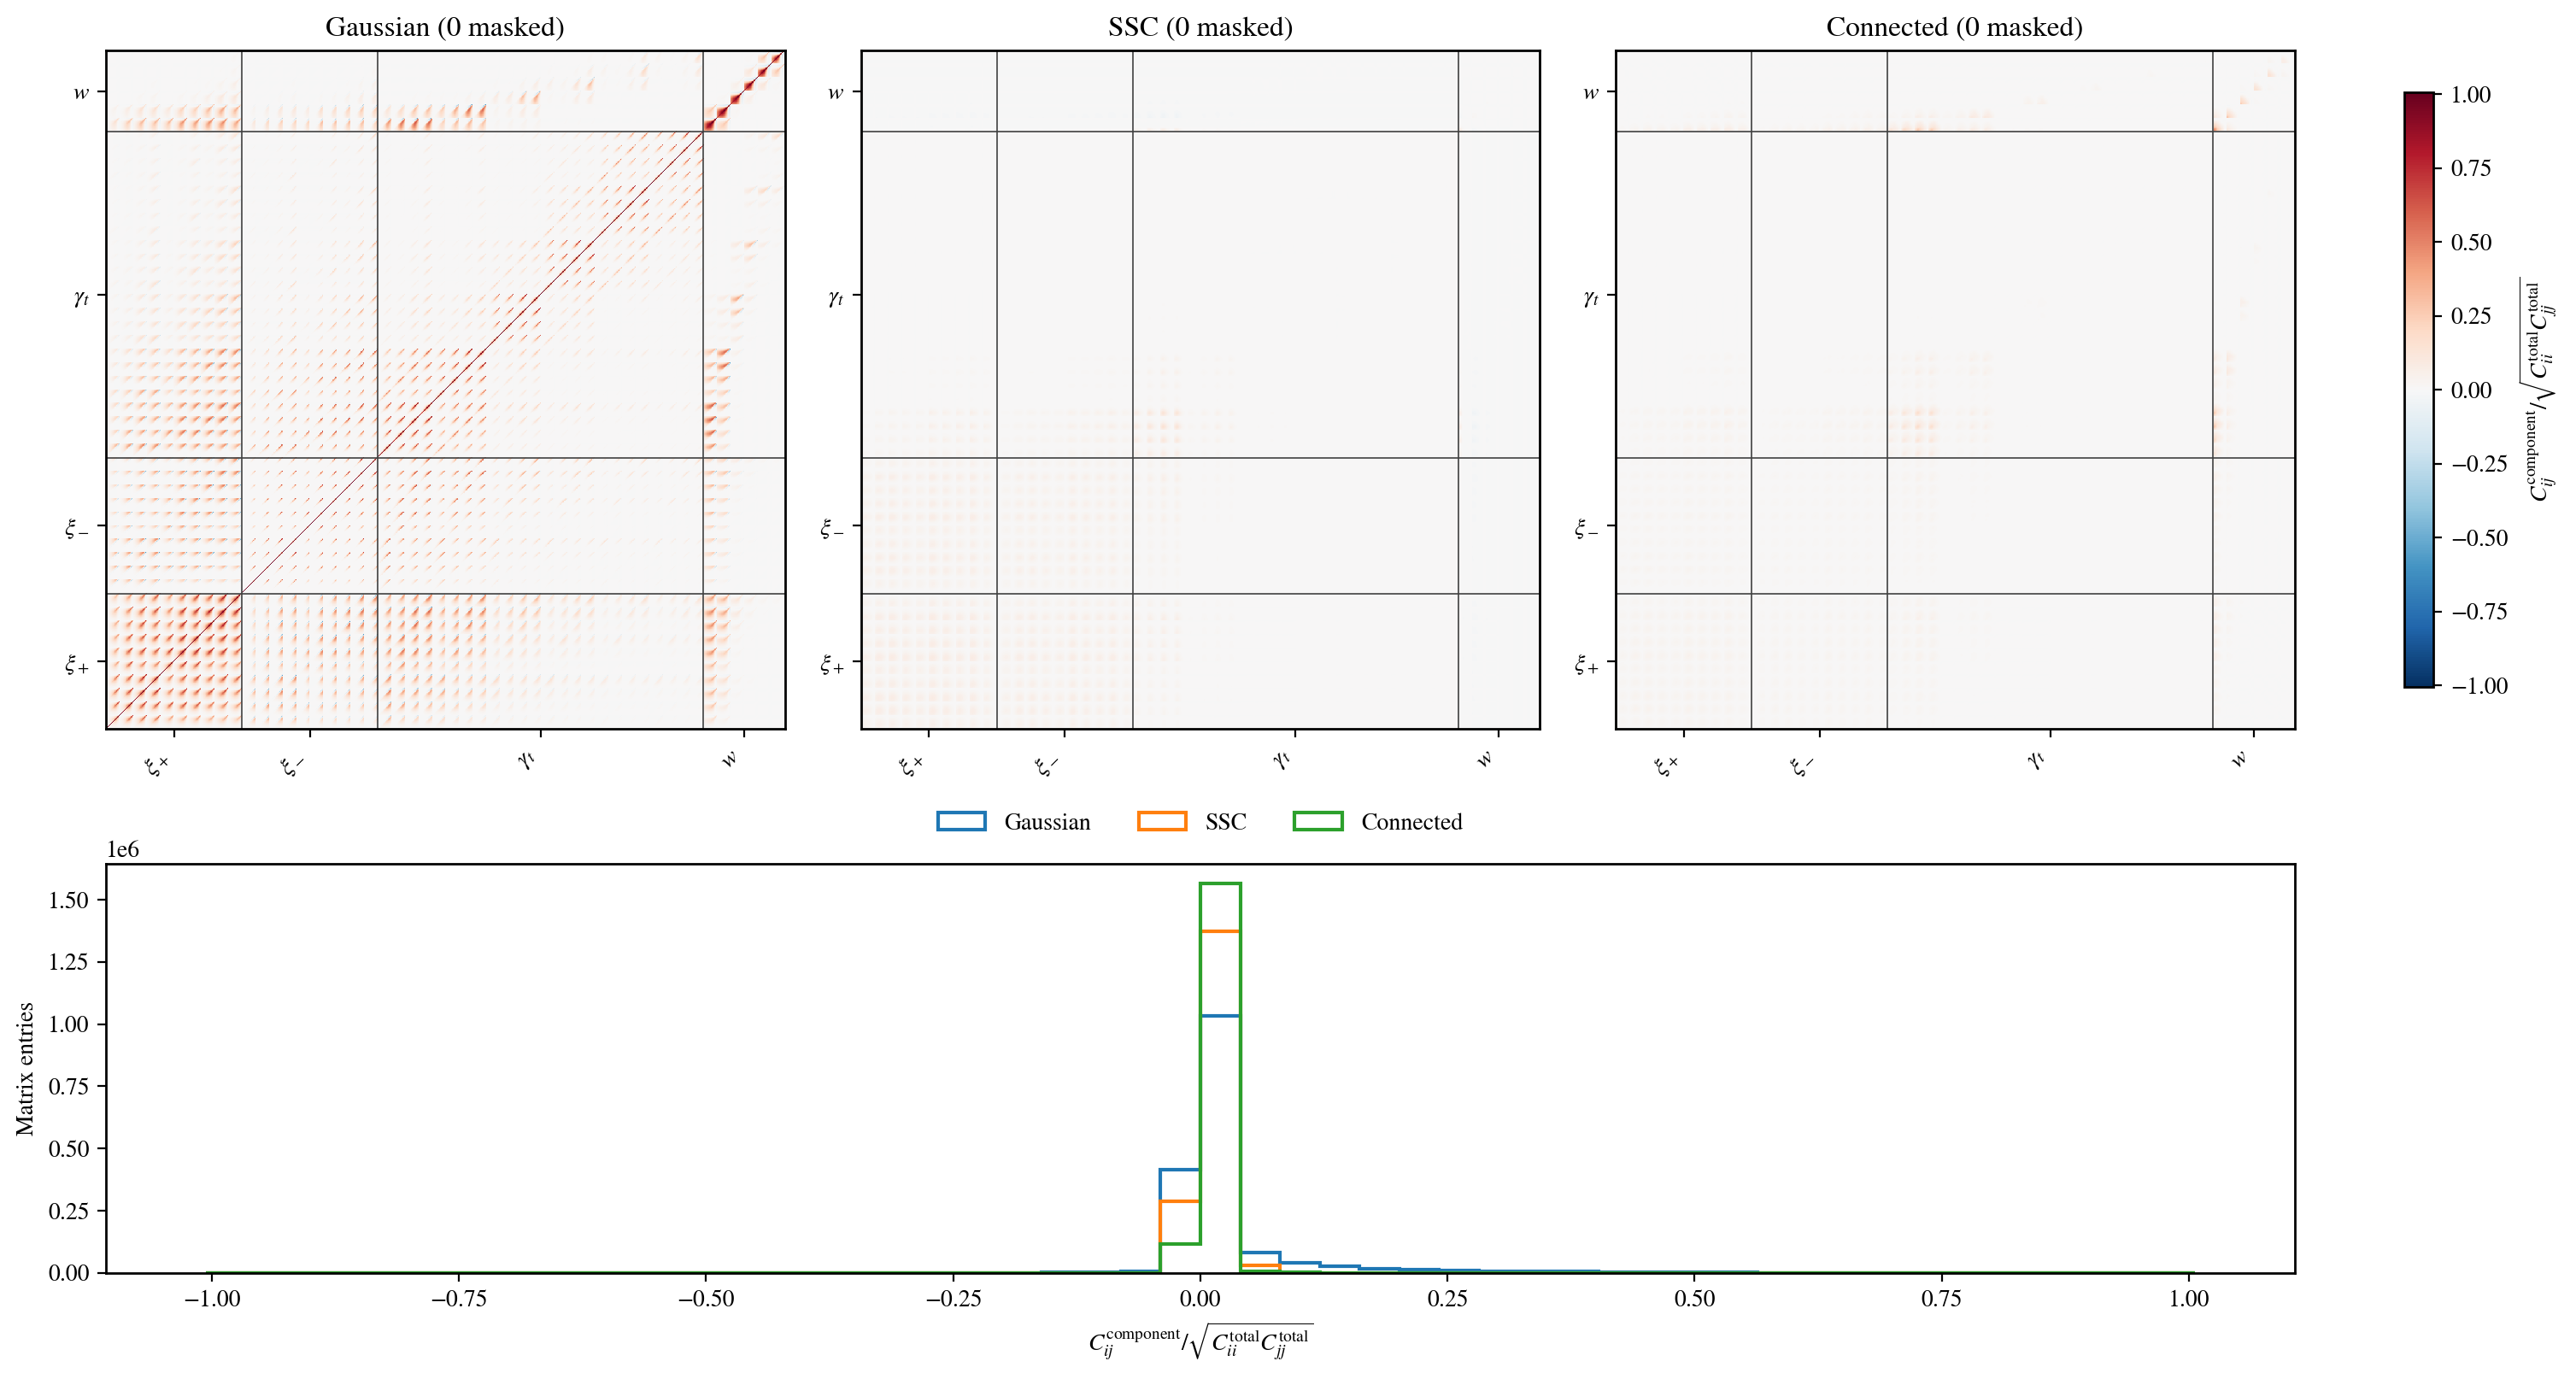

gaussian finite: True symmetric: True
ssc finite: True symmetric: True
cng finite: True symmetric: True
total finite: True symmetric: True


Full total positive definite: True
Minimum correlation eigenvalue: 0.007590995072663342


In [5]:
pcov.plot_correlation(
    covariance=forecast["total"],
    block_sizes=block_sizes,
    block_labels=block_labels,
)
pcov.plot_covariance_components(
    total=forecast["total"],
    components={
        "Gaussian": forecast["gaussian"],
        "SSC": forecast["ssc"],
        "Connected": forecast["cng"],
    },
    block_sizes=block_sizes,
    block_labels=block_labels,
    # Each component entry is divided by sqrt(C_ii C_jj) of the total.
    normalization="diagonal",
)
# np.array_equal requires every entry to equal its mirror exactly.
for name in ("gaussian", "ssc", "cng", "total"):
    matrix = forecast[name]
    print(name, "finite:", np.all(np.isfinite(matrix)),
          "symmetric:", np.array_equal(matrix, matrix.T))
# Eigenvalues are returned in ascending order: [0] is the smallest.
modes = cov.covariance_modes(matrix=forecast["total"])
print("Full total positive definite:", modes["positive_definite"])
print("Minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])


## Read the eigenvalues of each component

`cov.covariance_modes` returns more than the verdict printed above: whether every variance (diagonal entry) is positive, the raw eigenvalues of C and the eigenvalues of its correlation matrix. Applied to each component, it shows which parts behave like a covariance on their own:

- **G** must be positive definite by itself.
- **SSC** is a positively weighted sum of outer products, one per radial integration node, so it is positive semidefinite with rank at most the node count printed below, fewer than 1,300. Its other eigenvalues are zero in exact arithmetic; round-off scatters them around zero, so the verdict for SSC alone reflects round-off, not physics.
- **cNG** can have negative eigenvalues and even negative variances: the angular weights oscillate, and the projected trispectrum can lower some variances. Only the total must be positive definite.

The printed ratio of the smallest to the largest raw eigenvalue separates these cases. A ratio of order ±10⁻¹⁶, the relative round-off of double precision, marks an eigenvalue that is zero in exact arithmetic. A negative ratio many orders of magnitude larger, such as −10⁻³, marks a real negative mode. A positive-definite matrix can still give a tiny positive ratio, because shear and clustering variances differ by orders of magnitude; the correlation eigenvalues behind the verdict avoid that spread.

The last line uses **generalized eigenvalues** λ, the solutions of $C^{\rm total}v=\lambda\,C^{\rm G}v$. For any linear combination of the 1,300 entries, the ratio of its total variance to its Gaussian variance lies between the smallest and the largest λ. The largest λ minus 1 is the biggest fractional variance increase that SSC and cNG cause; a smallest λ below 1 means the signed cNG term lowers some variance below its Gaussian value.


In [6]:
# SSC is a positively weighted sum of one outer product per radial node.
print("Radial integration nodes (SSC rank bound):", forecast["geometry"].shape[1])
for name in ("gaussian", "ssc", "cng", "total"):
    report = cov.covariance_modes(matrix=forecast[name])
    # Raw eigenvalues ascend: [0] is the smallest, [-1] the largest.
    extreme_ratio = report["eigenvalues"][0]/report["eigenvalues"][-1]
    print(name, "| positive diagonal:", report["positive_diagonal"],
          "| positive definite:", report["positive_definite"],
          "| smallest/largest eigenvalue: %.1e" % extreme_ratio)
# lambda solves C_total v = lambda C_G v; for every combination v of the
# entries, the total/Gaussian variance ratio lies between min and max lambda.
variance_ratio = cov.compare_covariances(matrix=forecast["total"],
                                         reference=forecast["gaussian"])
generalized = variance_ratio["generalized_eigenvalues"]
print("Total/Gaussian variance ratio: %.3f to %.3f" % (generalized[0], generalized[-1]))

Radial integration nodes (SSC rank bound): 672


gaussian | positive diagonal: True | positive definite: True | smallest/largest eigenvalue: 6.4e-12


ssc | positive diagonal: True | positive definite: False | smallest/largest eigenvalue: -1.6e-16
cng | positive diagonal: False | positive definite: False | smallest/largest eigenvalue: -6.9e-03


total | positive diagonal: True | positive definite: True | smallest/largest eigenvalue: 4.0e-12
Total/Gaussian variance ratio: 0.941 to 6.151


## Compare error bars with and without non-Gaussian terms

`pcov.plot_covariance_diagonal` draws the **standard deviation** $\sigma_i=\sqrt{C_{ii}}$ of each entry against its angular bin; $\sigma_i$ is the forecast error bar of one data point. The first figure compares the Gaussian and total error bars for the first tomographic pair of each probe: ξ+ and ξ− of source bins (1,1), γt of lens bin 1 with source bin 1, and w of lens bin 1. The printed (probe, field A, field B) triplets confirm that choice.

The second figure passes the Gaussian matrix as `covariance_ref` and shows the percent change $100\,(\sigma^{\rm total}_i/\sigma^{\rm G}_i-1)$: how much SSC and cNG enlarge each error bar. A value slightly below zero means the signed cNG term lowers that variance.

The horizontal axis is the geometric bin center $\sqrt{\theta_{\min}\theta_{\max}}$ in arcmin, stored in `forecast["coordinate"]`. To inspect other pairs, set `panel_rows` to any row numbers of `forecast["rows"]` and change `panel_labels` to match.


(probe, field A, field B): [[0, 6, 6], [1, 6, 6], [2, 0, 6], [3, 0, 0]]


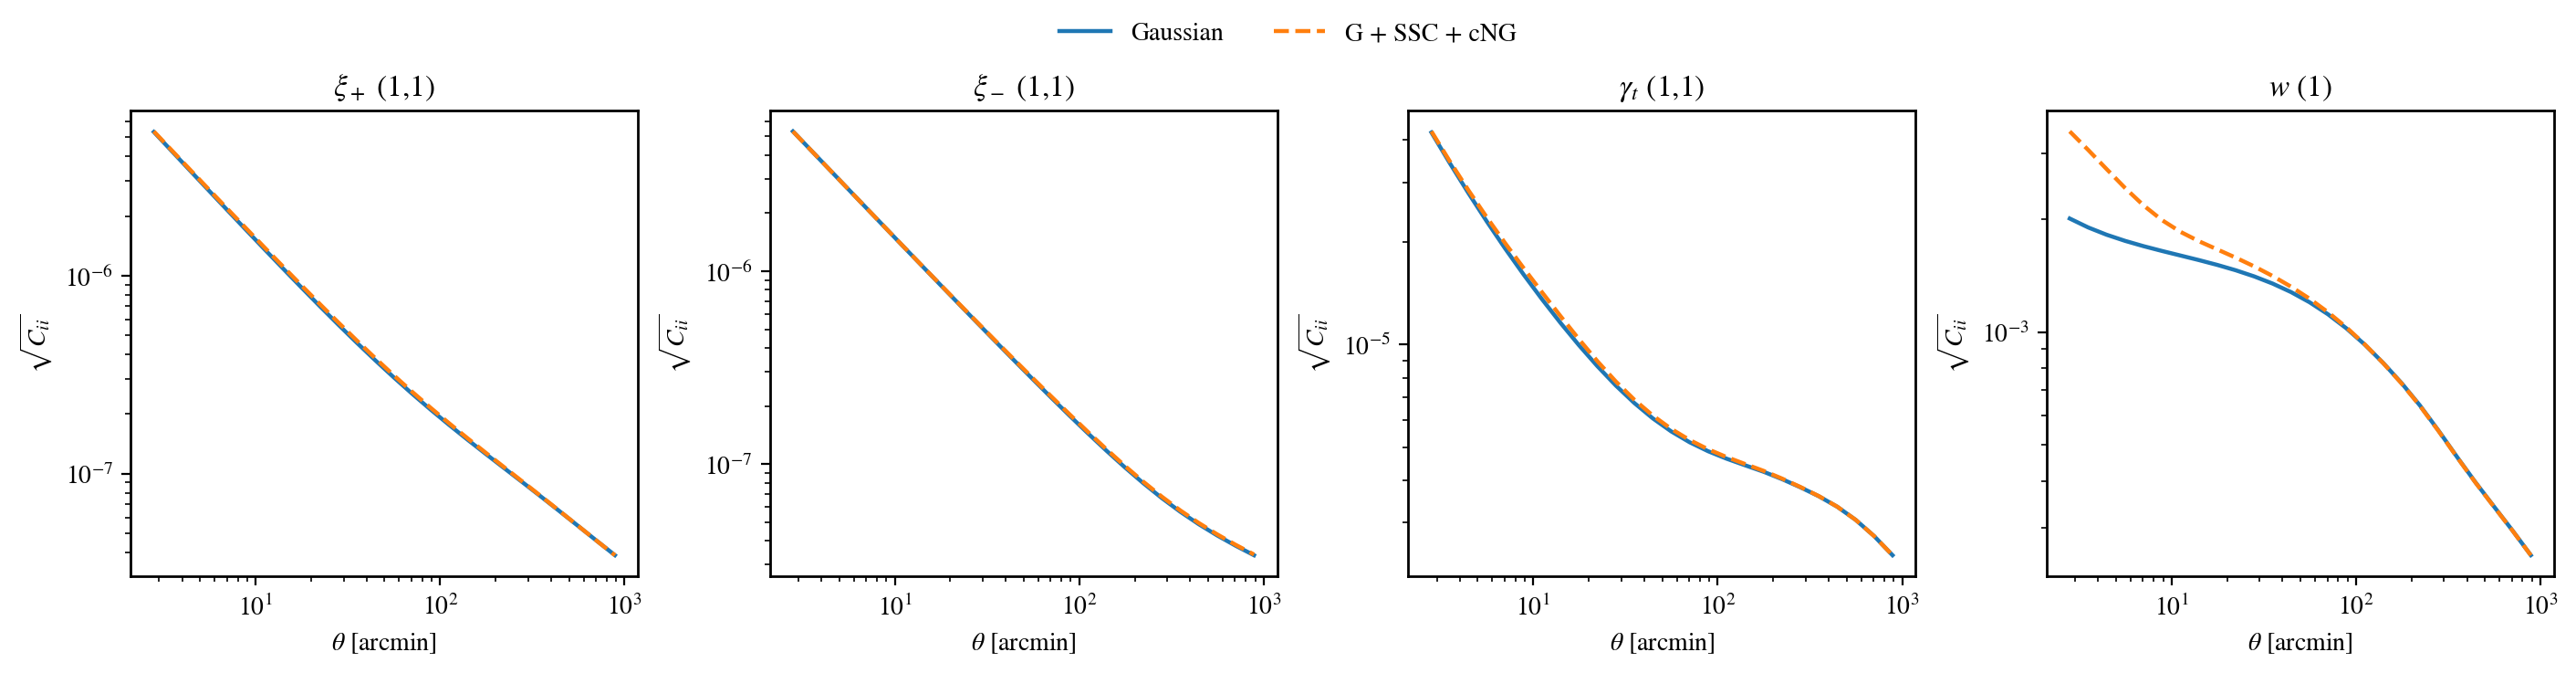

In [7]:
# A block starts at the running total of the sizes before it: entries
# 0, 260, 520 and 1144 start rows 0, 10, 20 and 44 of forecast["rows"].
ntheta = len(forecast["coordinate"])
panel_rows = (np.cumsum(block_sizes)-block_sizes)//ntheta
print("(probe, field A, field B):", forecast["rows"][panel_rows].tolist())
# Gather the 26 matrix indices of each chosen row, one row after another.
entries = []
for row in panel_rows:
    entries.extend(range(row*ntheta, (row+1)*ntheta))
panel = np.ix_(entries, entries)
panel_labels = [r"$\xi_+$ (1,1)", r"$\xi_-$ (1,1)", r"$\gamma_t$ (1,1)", r"$w$ (1)"]
pcov.plot_covariance_diagonal(
    theta_arcmin=forecast["coordinate"], panel_labels=panel_labels,
    covariances={"Gaussian": forecast["gaussian"][panel],
                 "G + SSC + cNG": forecast["total"][panel]}, figsize=(14, 3.6))

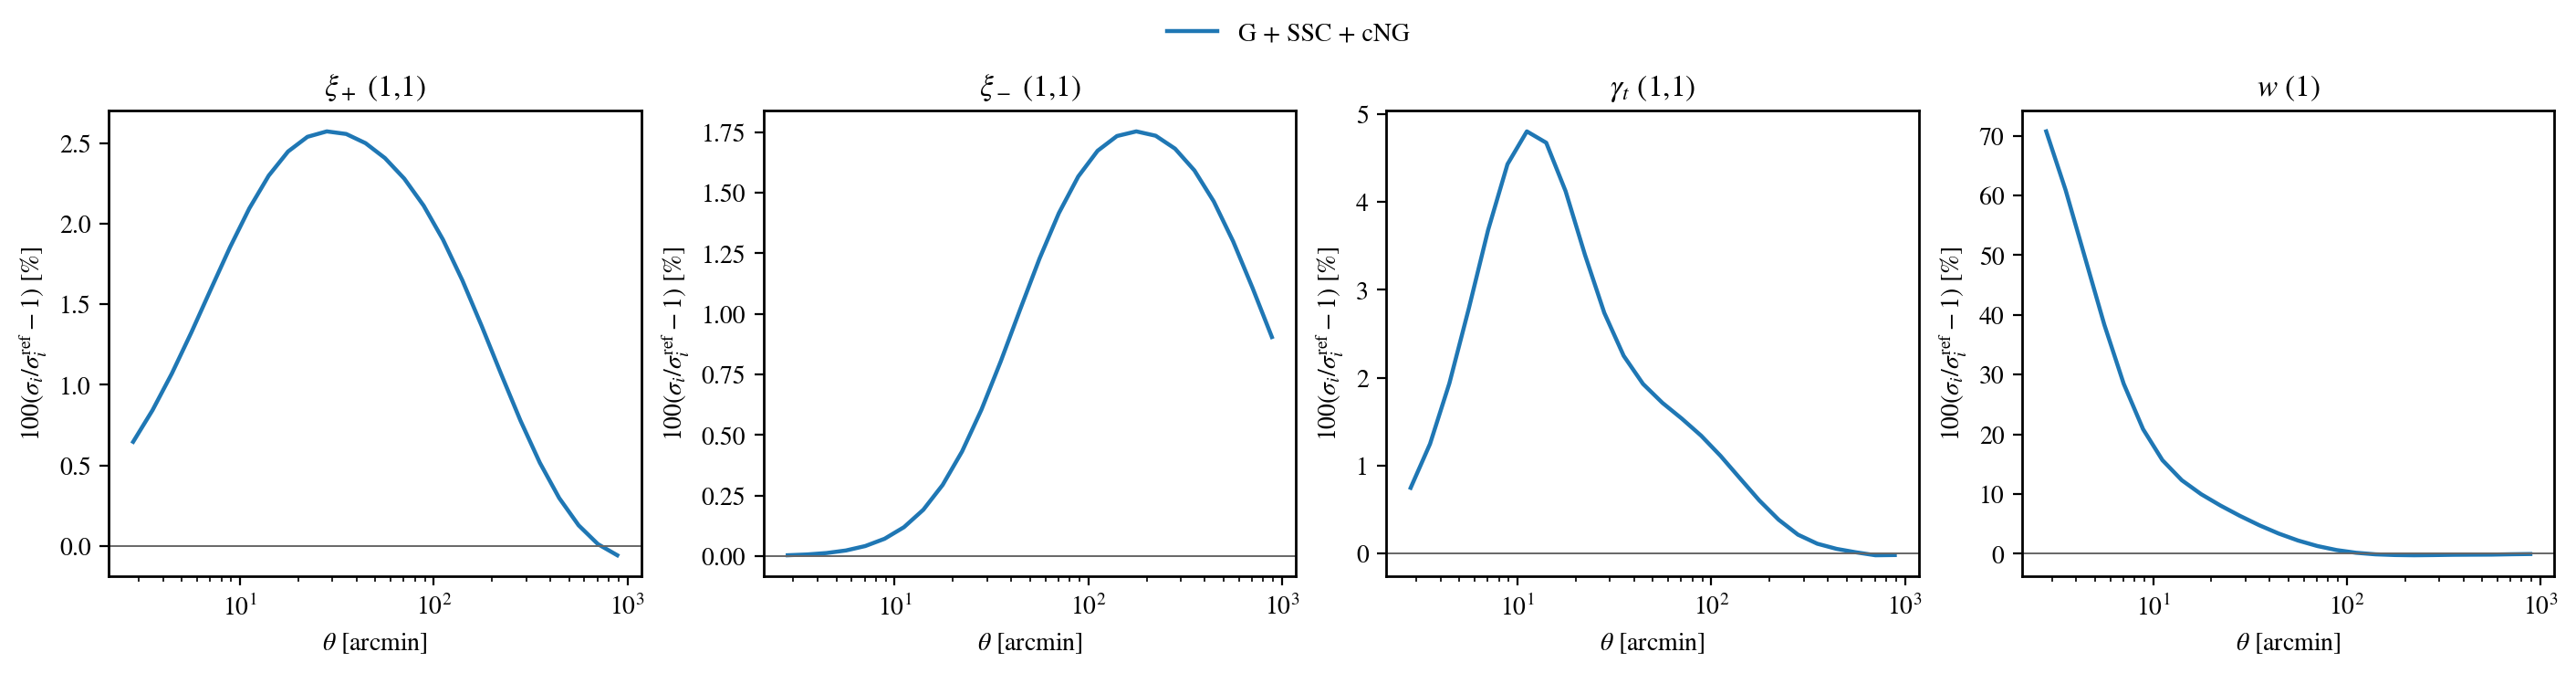

In [8]:
# With a reference the panels show 100 (sigma_total/sigma_G - 1) in percent:
# how much SSC and cNG enlarge each error bar.
pcov.plot_covariance_diagonal(
    theta_arcmin=forecast["coordinate"], panel_labels=panel_labels,
    covariances={"G + SSC + cNG": forecast["total"][panel]},
    covariance_ref=forecast["gaussian"][panel], figsize=(14, 3.6))

## Inspect the supplied scale selection

A **scale cut** removes data-vector entries whose model is not trusted. `data/DESY6.mask` keeps 541 of the 1,300 entries in this layout: 152 of ξ+, 58 of ξ−, 272 of γt and 59 of w. It removes small separations below a minimum angle that depends on the tomographic pair, the five largest angular bins (above about 315 arcmin) in every pair, and every γt and w entry of lens bin 2.

Applying the mask is an optional selection of the forecast; it does not make this the survey likelihood covariance. The active dummy dataset uses `ones.mask`, which keeps every entry.

A selection must act on **both matrix axes**: keeping entry i keeps row i and column i together. Original indices are saved so retained entries can be traced to the uncut ordering.

For a project whose dataset supplies a covariance in the same layout, `read_likelihood_covariance` and `select_likelihood_entries` in `cosmolike_notebook_utils.covariance.likelihood` read that matrix and apply its mask to every component. This notebook does not use them because no supplied matrix shares this layout.


In [9]:
# Column 0 is the entry index 0..1299; column 1 is 1 to keep it, 0 to cut it.
mask_table = np.loadtxt(fname=project/"data/DESY6.mask")
assert np.array_equal(mask_table[:, 0], np.arange(1300))
assert np.all(np.isin(mask_table[:, 1], [0, 1]))
# flatnonzero lists the kept entries' indices in ascending order.
indices = np.flatnonzero(mask_table[:, 1])
# np.ix_ selects every retained row crossed with every retained column.
selection = np.ix_(indices, indices)
selected = {"indices": indices}
for name in ("gaussian", "ssc", "cng", "total"):
    selected[name] = forecast[name][selection]
print("Retained entries:", len(indices))
selected_modes = cov.covariance_modes(matrix=selected["total"])
print("Selected total positive definite:", selected_modes["positive_definite"])
print("Minimum correlation eigenvalue:",
      selected_modes["correlation_eigenvalues"][0])


Retained entries: 541
Selected total positive definite: True
Minimum correlation eigenvalue: 0.007838083728618972


## Compare total and Gaussian correlations after the cut

`pcov.plot_correlation` can split one image between two matrices of the same size: here the selected total (G + SSC + cNG) and the selected Gaussian-only matrix, each divided by its own diagonal. The title names matrix triangles. "Lower" names the entries whose row index exceeds the column index; they show the total. "Upper" shows the Gaussian matrix. Because row 0 is drawn at the bottom, the total fills the half **above** the image diagonal.

Mirror-image points across the diagonal show the same pair of entries, so any difference between them is correlation added by SSC and cNG, which couple different angular scales and tomographic bins. The cut changes the block sizes, so the cell first counts the retained entries of each probe for the axis labels.


Retained entries per probe: [152, 58, 272, 59]


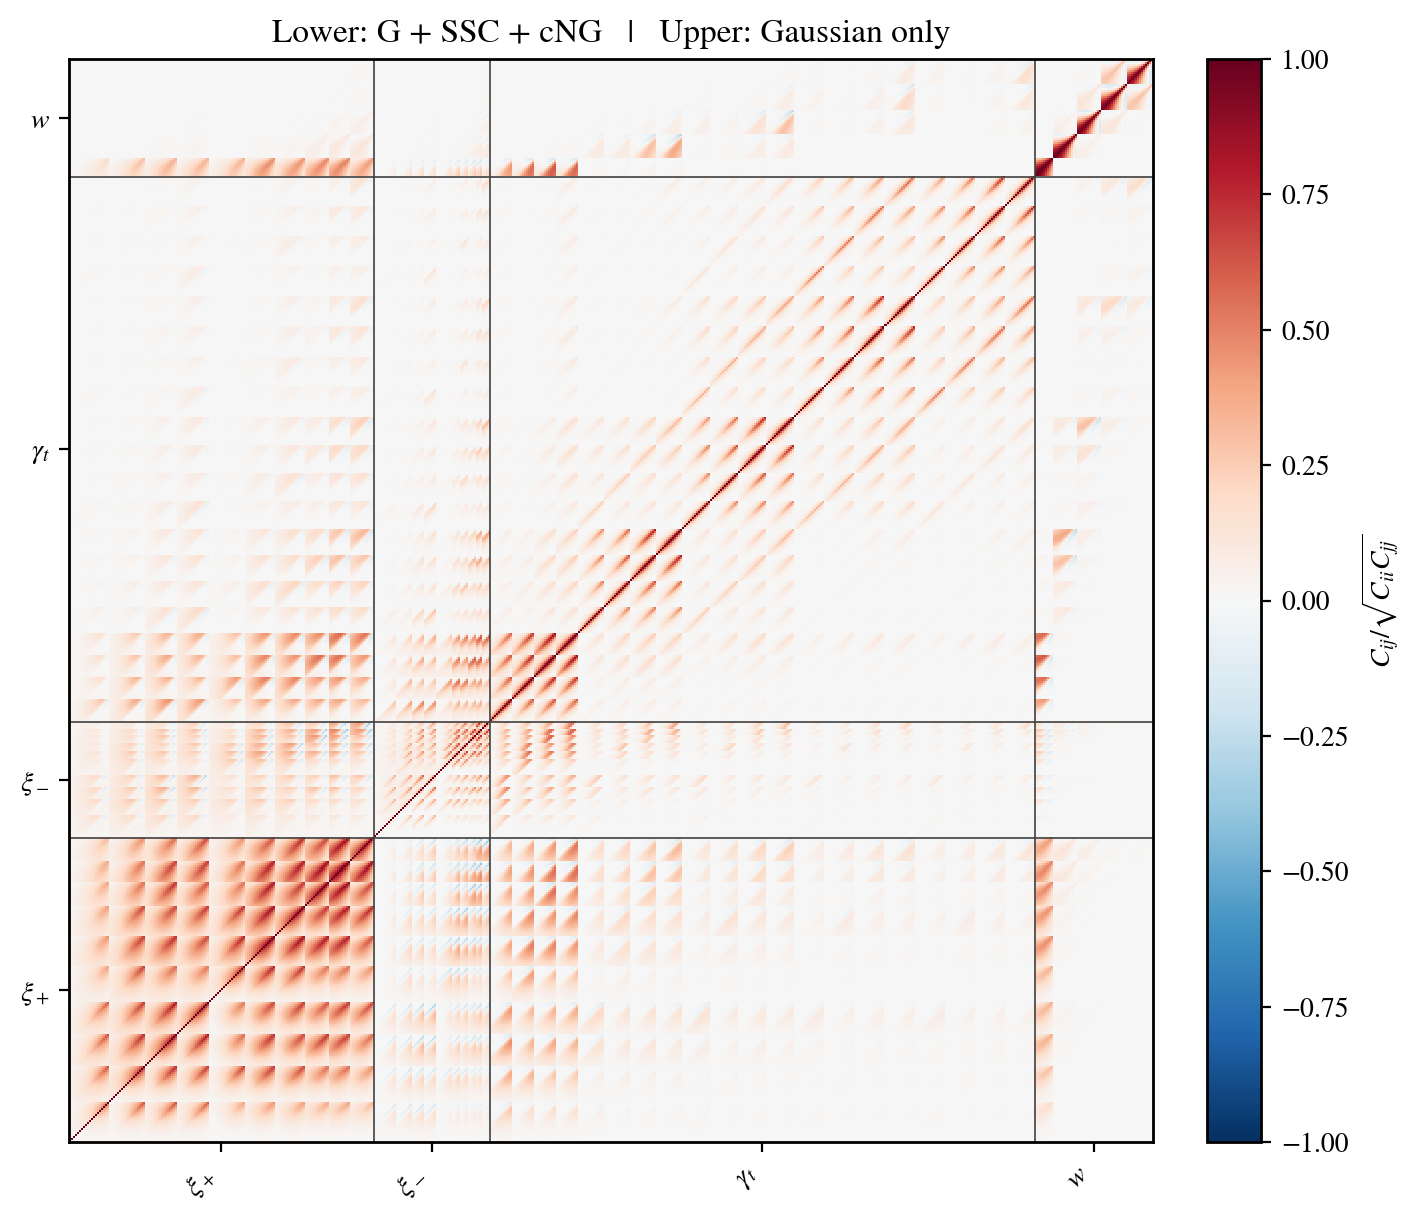

In [10]:
# indices ascend, so the retained entries of each probe stay contiguous in
# the selected matrix; counting them gives the cut axes' block sizes.
cut_block_sizes = []
start = 0
for count in block_sizes:
    inside = (indices >= start) & (indices < start+count)
    cut_block_sizes.append(int(np.count_nonzero(inside)))
    start += count
print("Retained entries per probe:", cut_block_sizes)
pcov.plot_correlation(
    covariance=selected["total"],
    covariance_ref=selected["gaussian"],
    block_sizes=cut_block_sizes, block_labels=block_labels,
    labels=("G + SSC + cNG", "Gaussian only"),
)

## Save components and inputs

The next cell writes three NumPy archives (`.npz` files: named arrays stored together in one zip file) under `covariance/`, where Git ignores NPZ outputs. Existing files with these names are replaced; nothing in `data/` is overwritten.

| File | Contents |
|---|---|
| `forecast_real.npz` | `gaussian`, `ssc`, `cng` and `total`; the mean `signal` [50, 26]; `rows`; `coordinate`; radial `geometry`; the resolved settings and stage times as JSON text (`settings_json`, `stages_json`); the archive's `.files` attribute lists every stored name |
| `forecast_selected.npz` | The 541 retained `indices` and the selected `gaussian`, `ssc`, `cng` and `total` |
| `forecast_camb.npz` | The CAMB power and background tables the forecast used |


In [11]:
save_forecast(
    result=forecast,
    filename=project/"covariance/forecast_real.npz",
)
# **selected passes each dictionary entry as a keyword argument, so every
# array is stored under its key (indices, gaussian, ssc, cng, total).
np.savez(file=project/"covariance/forecast_selected.npz", **selected)
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
print("Saved full and selected matrices and CAMB inputs under covariance/.")


Saved full and selected matrices and CAMB inputs under covariance/.


## Reload the saved archive

The next cell reads `forecast_real.npz` back and compares it with the arrays in memory. `np.load(..., allow_pickle=False)` reads numbers and text but refuses stored Python objects. `np.array_equal` demands identical values, which binary `.npz` storage preserves.

The resolved settings and stage times are JSON text; `json.loads` turns them back into dictionaries. The same calls reload this forecast in another notebook or script without recomputing it.


In [12]:
import json

# allow_pickle=False reads numbers and text only, never stored Python
# objects; each with block closes its archive file when it ends.
with np.load(project/"covariance/forecast_real.npz", allow_pickle=False) as archive:
    for name in ("gaussian", "ssc", "cng", "total", "signal", "rows", "coordinate"):
        print(name, archive[name].shape,
              "identical:", np.array_equal(archive[name], forecast[name]))
    saved_settings = json.loads(str(archive["settings_json"]))
    saved_stages = json.loads(str(archive["stages_json"]))
print("Saved accuracy_boost:", saved_settings["accuracy_boost"],
      "| integration_accuracy:", saved_settings["integration_accuracy"])
print("Saved stage times [s]:", saved_stages)
with np.load(project/"covariance/forecast_selected.npz", allow_pickle=False) as cut:
    print("Saved selection identical:", np.array_equal(cut["indices"], indices))

gaussian (1300, 1300) identical: True
ssc (1300, 1300) identical: True
cng (1300, 1300) identical: True
total (1300, 1300) identical: True
signal (50, 26) identical: True
rows (50, 3) identical: True
coordinate (26,) identical: True
Saved accuracy_boost: 1 | integration_accuracy: 0
Saved stage times [s]: {'all_pairs_gaussian_spectra': 1.4968912089243531, 'angular_and_mask_geometry': 1.543891750043258, 'gaussian_blocks': 2.639881749986671, 'observable_signal': 0.1980897089233622, 'shared_halo_response_and_trispectrum': 164.54144016595092, 'ssc_and_connected_projection': 0.2448566670063883, 'total': 170.67031320894603}
Saved selection identical: True
